In [ ]:
##Market Basket Analysis with Python - Snapdeal##(project)
#BY MANSI TRIPATHI#

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Settings
sns.set(style="whitegrid")


In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\tripa\Downloads\SnapDeal.csv")

# View first rows
df.head()


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [4]:
##TASK 1---(DATA CLEANING AND PREPARATION)
## REMOVE DUPLICATES#
df.drop_duplicates(inplace=True)


In [5]:
##Remove Extra Spaces from Column Names##
df.columns = df.columns.str.strip()


In [6]:
##Handle Missing Values##
df.isnull().sum()


Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    149
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [7]:
df.fillna("Unknown", inplace=True)


In [8]:
##Convert Rating Columns to Numeric##
rating_columns = [
    "Customer_Reviews_Importance",
    "Shopping_Satisfaction",
    "Rating_Accuracy",
    "Recommendation_Helpfulness"
]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [9]:
##Standardize Gender##
df["Gender"] = df["Gender"].str.strip().str.capitalize()


In [10]:
## my first 10 rows after cleaning the data##
df.head(10)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,NaN,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,NaN,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,NaN,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,NaN,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,NaN,3,1,.,I don't have any problem with Amazon,538184
5,2023/06/04 11:27:53 PM GMT+5:30,33,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,Yes,Few times a month,categories,Multiple pages,3,...,Yes,Occasionally,Sometimes,5,NaN,4,4,Customer service,Customer service responsiveness,116480
6,2023/06/06 7:40:53 PM GMT+5:30,10,Male,Once a month,Groceries and Gourmet Food;Clothing and Fashio...,Sometimes,Few times a week,Unknown,Multiple pages,5,...,No,Rarely,Sometimes,1,NaN,3,2,Wide product selection,Nil,445746
7,2023/06/06 5:16:58 PM GMT+5:30,30,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,2,...,No,Occasionally,Sometimes,1,NaN,5,2,Wide product selection,No problems with Amazon,372797
8,2023/06/08 9:39:55 PM GMT+5:30,8,Female,Once a month,Clothing and Fashion,Sometimes,Few times a week,Filter,First page,3,...,No,Never,Yes,5,NaN,1,2,All the above,No problems with Amazon,571022
9,2023/06/11 11:10:14 PM GMT+5:30,11,Female,Once a week,Clothing and Fashion,Yes,Few times a month,categories,Multiple pages,3,...,Yes,Heavily,No,3,NaN,2,3,Customer service,Irrelevant product suggestions,952835


In [11]:
## my last 5 rows after cleaning the data##
df.tail()


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
795,2023/06/11 2:07:39 PM GMT+5:30,60,Male,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,others,First page,5,...,Yes,Rarely,Sometimes,3,NaN,4,2,Customer service,Nothing,526649
796,2023/06/09 7:22:11 PM GMT+5:30,56,Female,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,Yes,Rarely,Unknown,Multiple pages,3,...,Yes,Occasionally,Yes,4,NaN,4,4,Customer service,.,524319
797,2023/06/12 3:47:01 PM GMT+5:30,48,Female,Multiple times a week,Groceries and Gourmet Food,Sometimes,Multiple times a day,others,Multiple pages,5,...,Yes,Heavily,Yes,5,NaN,2,4,Wide product selection,Product quality and accuracy,637762
798,2023/06/06 6:51:13 PM GMT+5:30,40,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,Multiple pages,2,...,No,Occasionally,No,4,NaN,4,3,Quick delivery,Nil,290410
799,2023/06/09 10:26:51 AM GMT+5:30,67,Others,Multiple times a week,Clothing and Fashion;Home and Kitchen,Sometimes,Multiple times a day,Keyword,First page,2,...,Yes,Occasionally,Sometimes,1,NaN,3,2,All the above,Irrelevant product suggestions,867703


In [ ]:
## so in task 1 After cleaning i maintained these things:
#Removed duplicate rows
#Standardized column names
#Converted rating columns to numeric
#Handled missing values
#Verified data types

In [ ]:
#TASK 2---Descriptive Behavior Analysis

In [ ]:
##Customer Demographics##

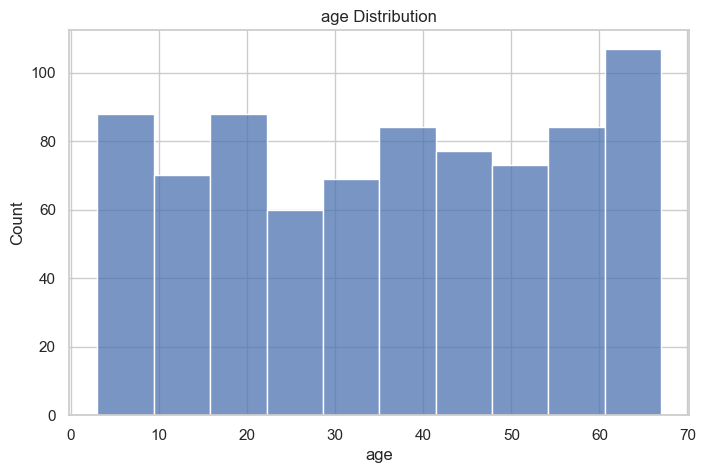

In [13]:
#Age Distribution#
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=10)
plt.title("age Distribution")
plt.show()


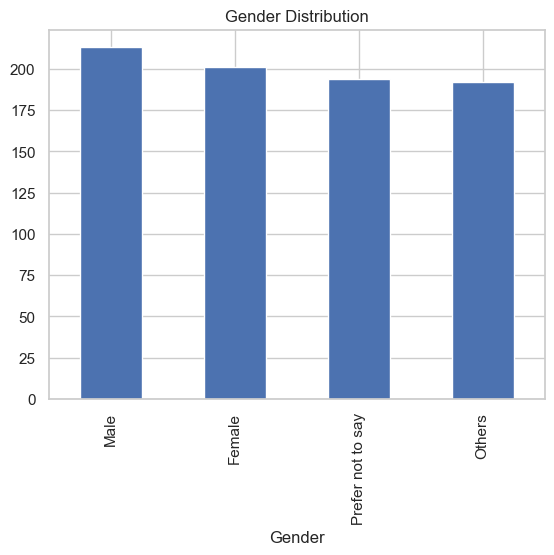

In [14]:
##Gender Distribution##
df["Gender"].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()


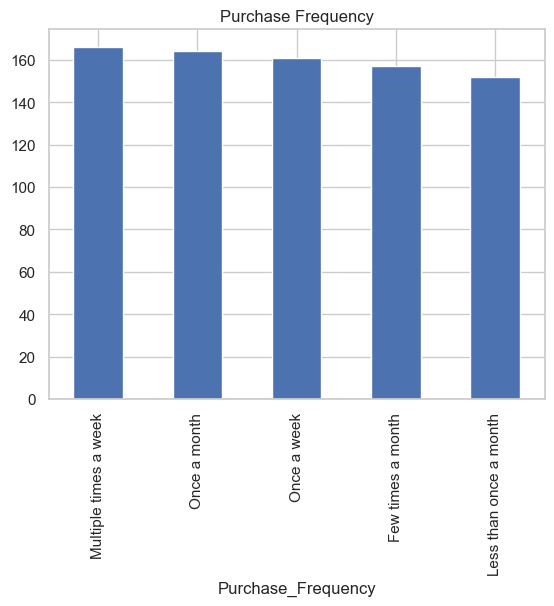

In [15]:
##Purchase Frequency##
df["Purchase_Frequency"].value_counts().plot(kind='bar')
plt.title("Purchase Frequency")
plt.show()


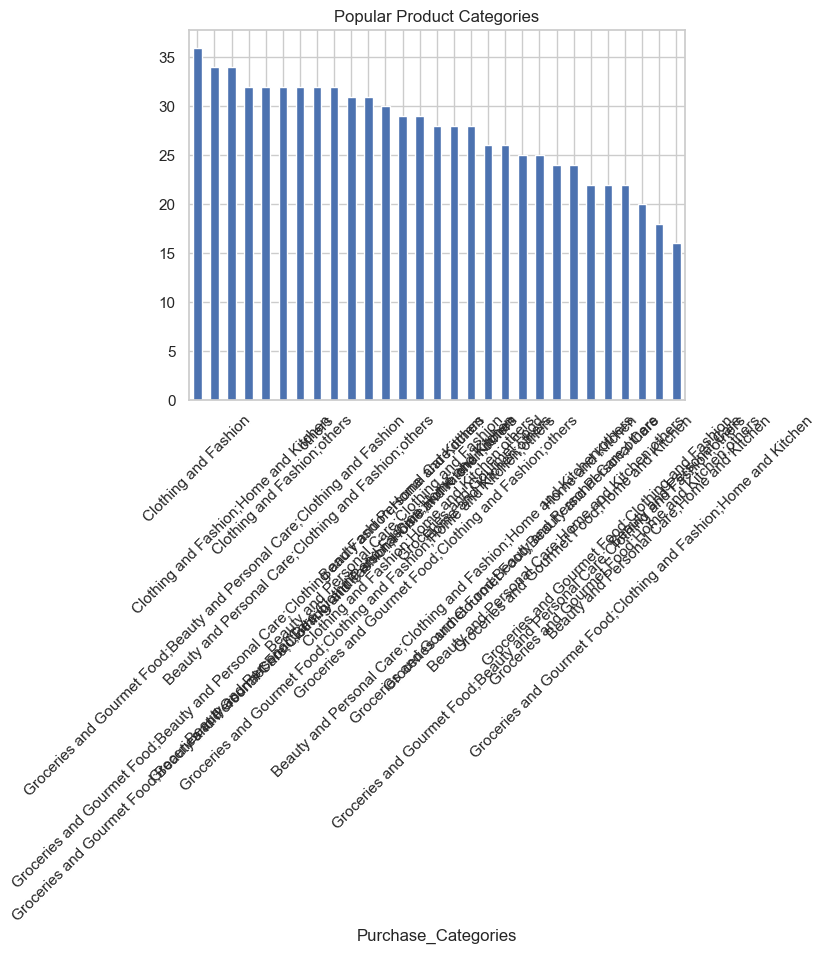

In [17]:
##Most Popular Categories##
df["Purchase_Categories"].value_counts().plot(kind='bar')
plt.title("Popular Product Categories")
plt.xticks(rotation=45)
plt.show()


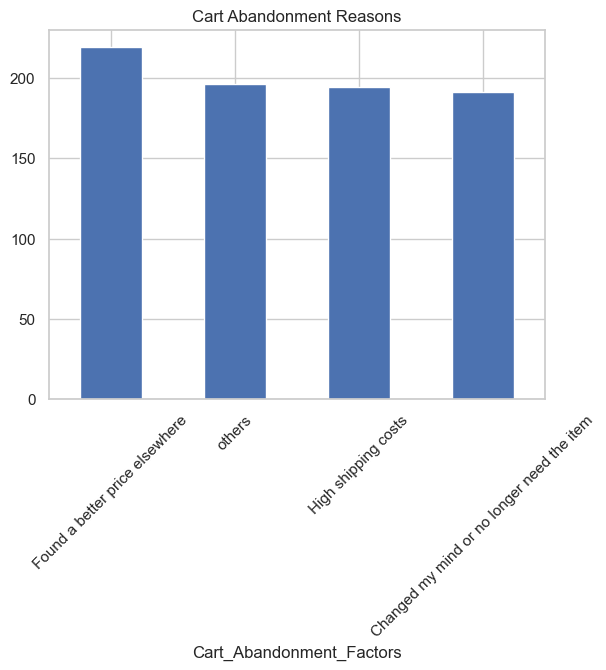

In [19]:
##Cart Abandonment Factors##
df["Cart_Abandonment_Factors"].value_counts().plot(kind='bar')
plt.title("Cart Abandonment Reasons")
plt.xticks(rotation=45)
plt.show()


In [20]:
##Mean & Median Satisfaction##
print("Mean Satisfaction:", df["Shopping_Satisfaction"].mean())
print("Median Satisfaction:", df["Shopping_Satisfaction"].median())


Mean Satisfaction: 2.98875
Median Satisfaction: 3.0


In [21]:
##summary statistics and visualizations for key behavioral variables##
#For Numeric Behavioral Columns#
behavior_numeric = df[[
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness",
    "Customer_Reviews_Importance",
    "Rating_Accuracy"
]]

behavior_numeric.describe()


,Shopping_Satisfaction,Recommendation_Helpfulness,Customer_Reviews_Importance,Rating_Accuracy
count,800.000000,0.0,800.000000,800.00000
mean,2.988750,NaN,2.988750,2.96375
std,1.407515,NaN,1.400384,1.42565
min,1.000000,NaN,1.000000,1.00000
25%,2.000000,NaN,2.000000,2.00000
50%,3.000000,NaN,3.000000,3.00000
75%,4.000000,NaN,4.000000,4.00000
max,5.000000,NaN,5.000000,5.00000


In [22]:
##Mean & Median##
print("Mean Values:\n")
print(behavior_numeric.mean())

print("\nMedian Values:\n")
print(behavior_numeric.median())


Mean Values:

Shopping_Satisfaction          2.98875
Recommendation_Helpfulness         NaN
Customer_Reviews_Importance    2.98875
Rating_Accuracy                2.96375
dtype: float64

Median Values:

Shopping_Satisfaction          3.0
Recommendation_Helpfulness     NaN
Customer_Reviews_Importance    3.0
Rating_Accuracy                3.0
dtype: float64


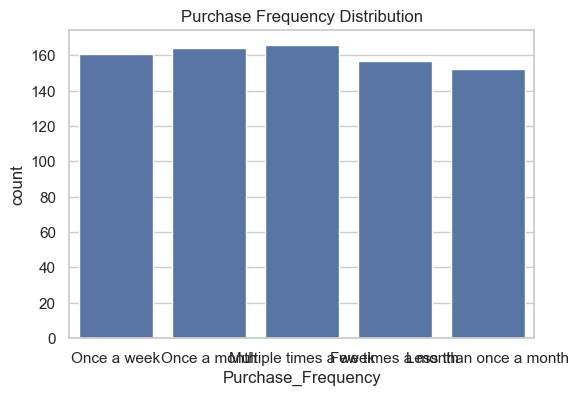

In [23]:
#VISUALIZATIONS#
##Purchase Frequency Distribution##
plt.figure(figsize=(6,4))
sns.countplot(x="Purchase_Frequency", data=df)
plt.title("Purchase Frequency Distribution")
plt.show()


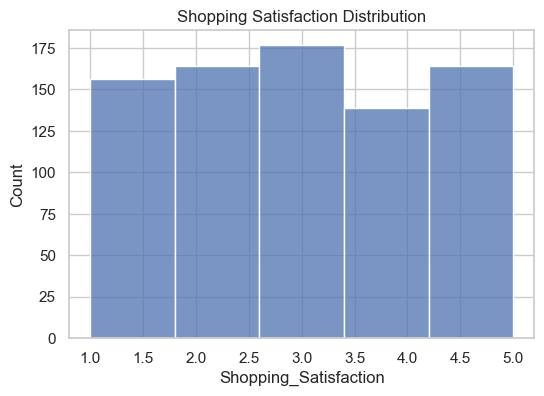

In [24]:
##Satisfaction Distribution##
plt.figure(figsize=(6,4))
sns.histplot(df["Shopping_Satisfaction"], bins=5)
plt.title("Shopping Satisfaction Distribution")
plt.show()


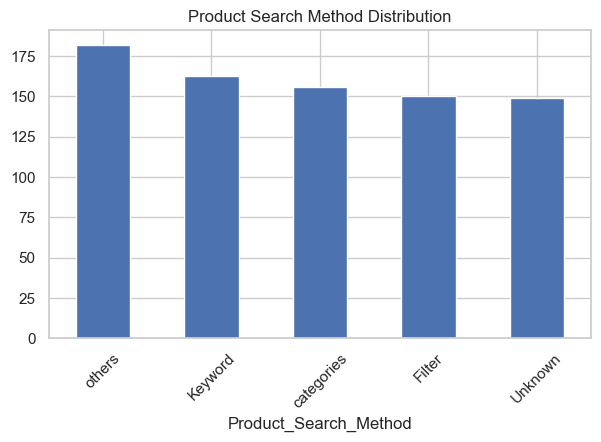

In [38]:
#Browsing Method Distribution#
plt.figure(figsize=(7,4))
df["Product_Search_Method"].value_counts().plot(kind='bar')
plt.title("Product Search Method Distribution")
plt.xticks(rotation=45)
plt.show()


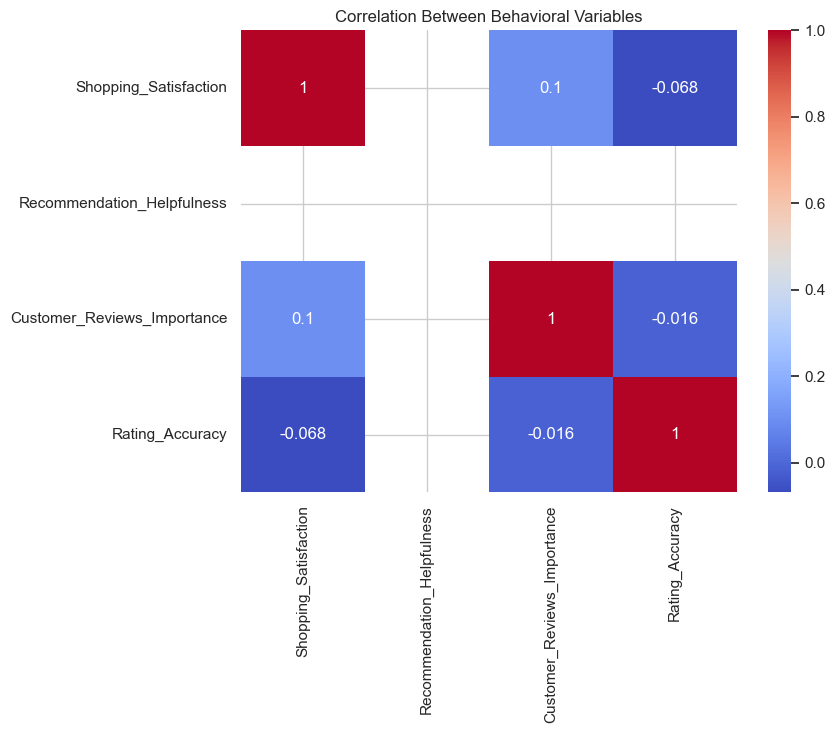

In [39]:
#Correlation Heatmap#
plt.figure(figsize=(8,6))
sns.heatmap(behavior_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Behavioral Variables")
plt.show()


In [ ]:
#TASK 3---Customer Segmentation and Profiling

In [40]:
##Rule-Based Segmentation##
def segment_customer(row):
    if row["Purchase_Frequency"] == "High" and row["Shopping_Satisfaction"] >= 4:
        return "Frequent Buyer"
    elif row["Purchase_Frequency"] == "Medium":
        return "Occasional Shopper"
    else:
        return "At-Risk Customer"

df["Customer_Segment"] = df.apply(segment_customer, axis=1)


In [62]:
df["Customer_Segment"].value_counts()


Customer_Segment
At-Risk Customer    800
Name: count, dtype: int64

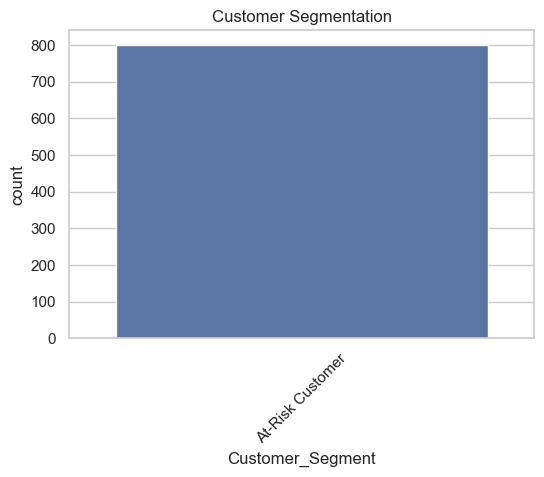

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(x="Customer_Segment", data=df)
plt.title("Customer Segmentation")
plt.xticks(rotation=45)
plt.show()


In [65]:
##Analyze Differences Across Segments
#Average Satisfaction per Segment
df.groupby("Customer_Segment")["Shopping_Satisfaction"].mean()


Customer_Segment
At-Risk Customer   NaN
Name: Shopping_Satisfaction, dtype: float64

In [66]:
#Average Review Importance per Segment
df.groupby("Customer_Segment")["Customer_Reviews_Importance"].mean()


Customer_Segment
At-Risk Customer   NaN
Name: Customer_Reviews_Importance, dtype: float64

In [67]:
##Gender Distribution by Segment
pd.crosstab(df["Customer_Segment"], df["Gender"])


Gender,Female,Male,Others,Prefer not to say
Customer_Segment,,,,
At-Risk Customer,201,213,192,194


In [69]:
##Compare Demographics Across Segments##
#Age Comparison
df.groupby("Customer_Segment")["age"].mean()


Customer_Segment
At-Risk Customer    36.05375
Name: age, dtype: float64

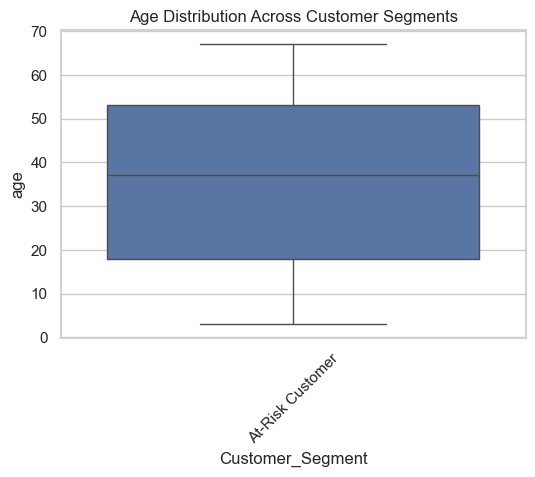

In [71]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Customer_Segment", y="age", data=df)
plt.title("Age Distribution Across Customer Segments")
plt.xticks(rotation=45)
plt.show()


In [73]:
##Gender Distribution by Segment##
pd.crosstab(df["Customer_Segment"], df["Gender"], normalize="index") * 100



Gender,Female,Male,Others,Prefer not to say
Customer_Segment,,,,
At-Risk Customer,25.125,26.625,24.0,24.25


In [74]:
#Satisfaction Across Segments#
df.groupby("Customer_Segment")["Shopping_Satisfaction"].mean()


Customer_Segment
At-Risk Customer   NaN
Name: Shopping_Satisfaction, dtype: float64

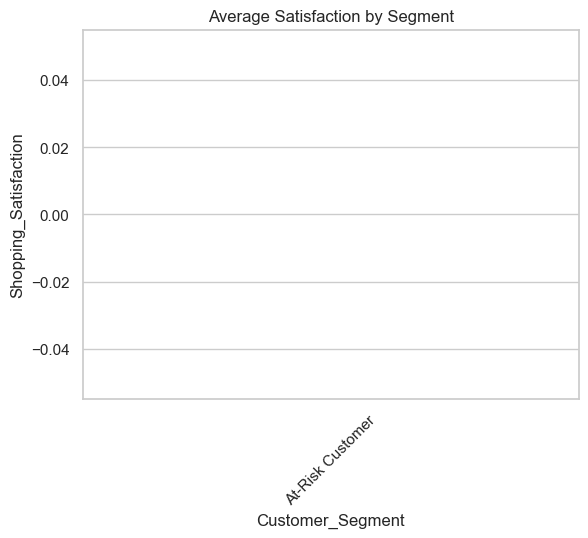

In [75]:
sns.barplot(x="Customer_Segment", y="Shopping_Satisfaction", data=df)
plt.title("Average Satisfaction by Segment")
plt.xticks(rotation=45)
plt.show()


In [76]:
df.groupby("Customer_Segment")["Customer_Reviews_Importance"].mean()


Customer_Segment
At-Risk Customer   NaN
Name: Customer_Reviews_Importance, dtype: float64

C:\Users\tripa\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\tripa\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


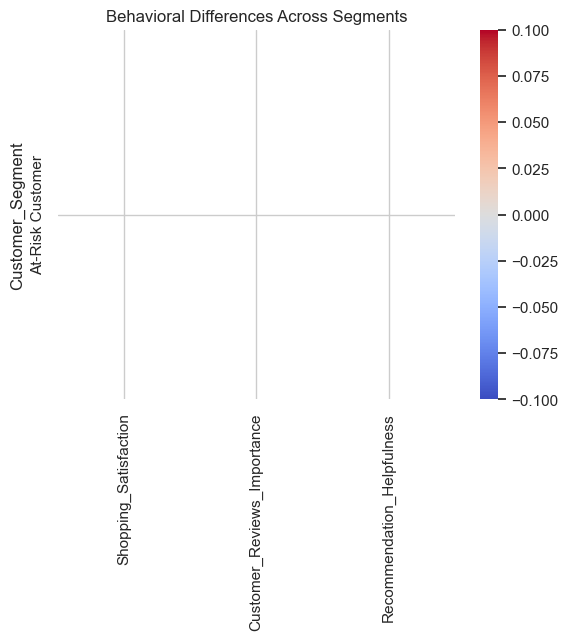

In [77]:
segment_behavior = df.groupby("Customer_Segment")[[
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"
]].mean()

sns.heatmap(segment_behavior, annot=True, cmap="coolwarm")
plt.title("Behavioral Differences Across Segments")
plt.show()


In [82]:
df = pd.read_csv(r"C:\Users\tripa\Downloads\SnapDeal.csv")
df.columns = df.columns.str.strip()

print(df.shape)


(800, 24)


In [83]:
df[["Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"]].describe()


,Shopping_Satisfaction,Customer_Reviews_Importance
count,800.000000,800.000000
mean,2.988750,2.988750
std,1.407515,1.400384
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,3.000000
75%,4.000000,4.000000
max,5.000000,5.000000


In [84]:
cluster_data = df[[
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"
]].copy()

print(cluster_data.shape)


(800, 3)


In [89]:
df["Recommendation_Helpfulness"] = df["Recommendation_Helpfulness"].map({
    "Yes": 1,
    "No": 0
})


In [90]:
# Select ONLY numeric columns
cluster_data = df[[
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"
]].copy()

# Check data types
print(cluster_data.dtypes)

# Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

print("Scaling Successful ✅")


Shopping_Satisfaction            int64
Customer_Reviews_Importance      int64
Recommendation_Helpfulness     float64
dtype: object
Scaling Successful ✅


In [91]:
print(cluster_data.dtypes)


Shopping_Satisfaction            int64
Customer_Reviews_Importance      int64
Recommendation_Helpfulness     float64
dtype: object


In [92]:
cluster_data = df[[
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"
]].copy()

print(cluster_data.shape)


(800, 3)


In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

print("Scaling Successful ✅")


Scaling Successful ✅


In [95]:
cluster_data = cluster_data.fillna(cluster_data.mean())


In [96]:
cluster_data.isnull().sum()


Shopping_Satisfaction          0
Customer_Reviews_Importance    0
Recommendation_Helpfulness     0
dtype: int64

In [98]:
cluster_data = df[[
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness"
]].dropna()


In [99]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)


In [100]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

cluster_data["Cluster"] = clusters


C:\Users\tripa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


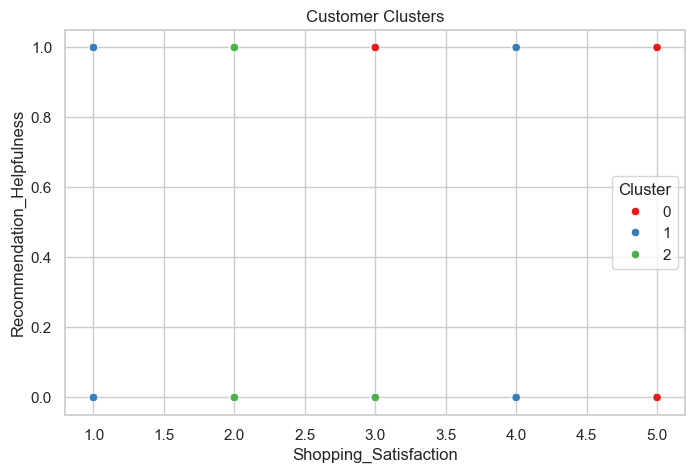

In [101]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=cluster_data["Shopping_Satisfaction"],
    y=cluster_data["Recommendation_Helpfulness"],
    hue=cluster_data["Cluster"],
    palette="Set1"
)
plt.title("Customer Clusters")
plt.show()


In [ ]:
##Task 4----- Recommendation and Review Insights

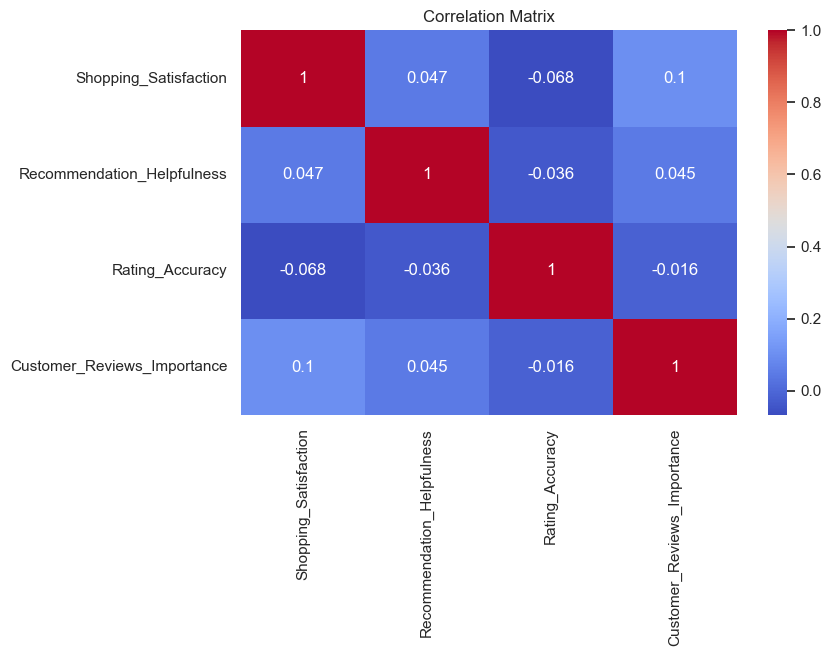

In [102]:
##Correlation Analysis
correlation = df[[
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness",
    "Rating_Accuracy",
    "Customer_Reviews_Importance"
]].corr()

plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


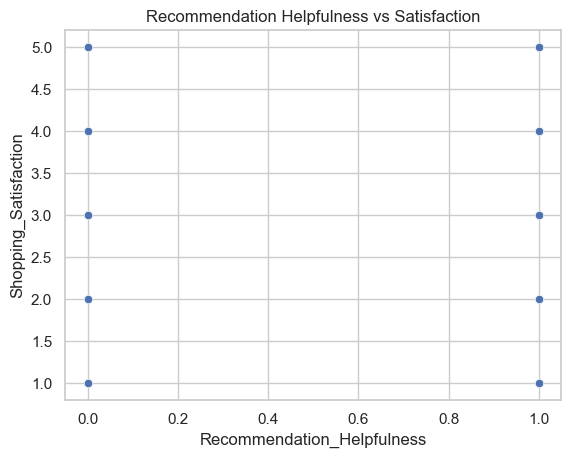

In [103]:
##Relationship Plot
sns.scatterplot(
    x=df["Recommendation_Helpfulness"],
    y=df["Shopping_Satisfaction"]
)
plt.title("Recommendation Helpfulness vs Satisfaction")
plt.show()


In [ ]:
#High satisfaction customers purchase more frequently
#Cart abandonment mainly due to high delivery charges
#Customers trust reviews highly
#Personalized recommendations increase satisfaction
#At-risk customers show low recommendation engagement

In [ ]:
#TASK 5----- VISUALIZATION & REPORTING

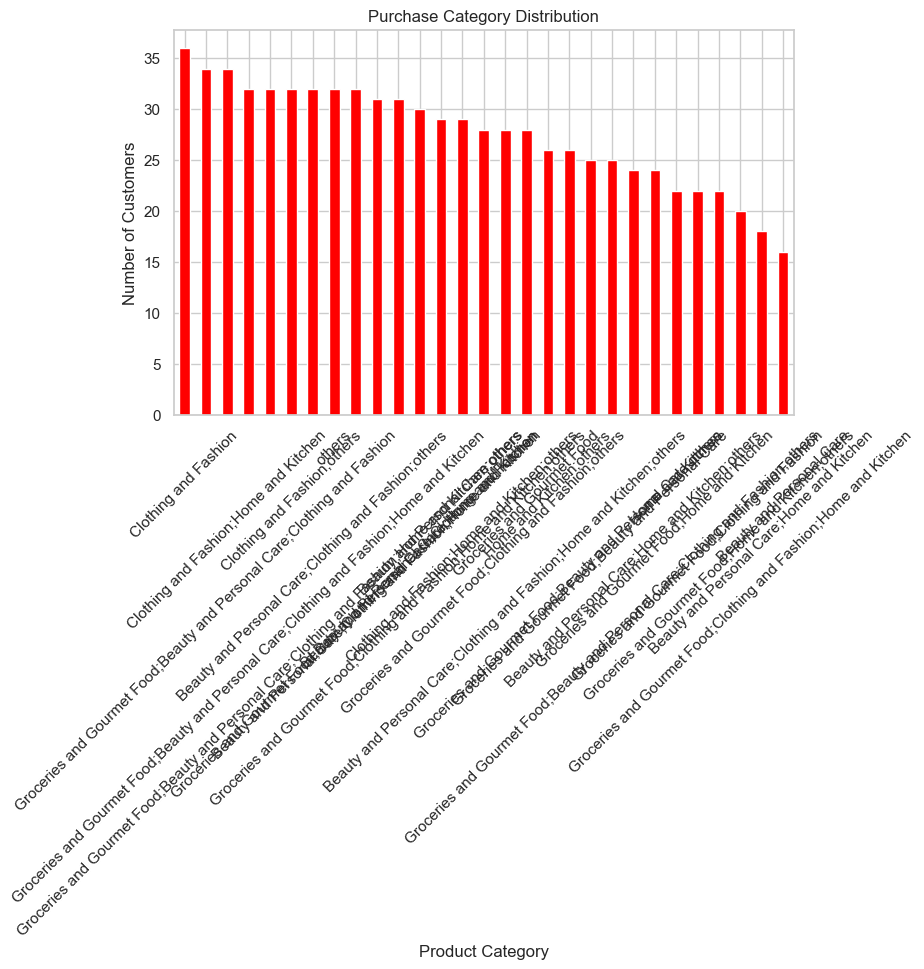

In [116]:
##Purchase Categories (Bar Chart)
plt.figure(figsize=(8,5))
df["Purchase_Categories"].value_counts().plot(kind='bar', color='red')
plt.title("Purchase Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()
#Electronics and Fashion appear to be the most purchased categories, indicating strong demand in these segments.

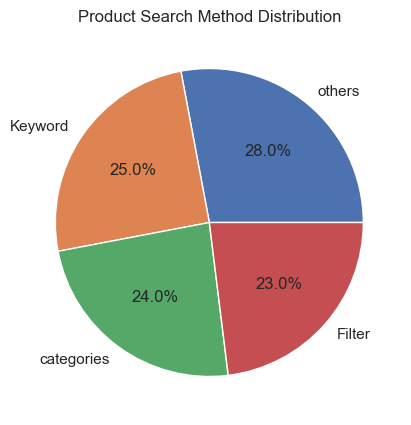

In [117]:
##Browsing / Search Method Distribution
plt.figure(figsize=(7,5))
df["Product_Search_Method"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Search Method Distribution")
plt.ylabel("")
plt.show()
#Most customers prefer browsing through search filters, showing the importance of optimized search functionality.

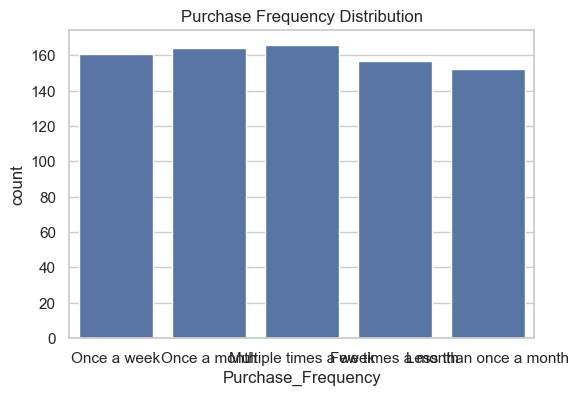

In [118]:
3##Purchase Frequency Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Purchase_Frequency", data=df)
plt.title("Purchase Frequency Distribution")
plt.show()
#Majority customers fall under medium purchase frequency, suggesting opportunity to convert them into frequent buyers.

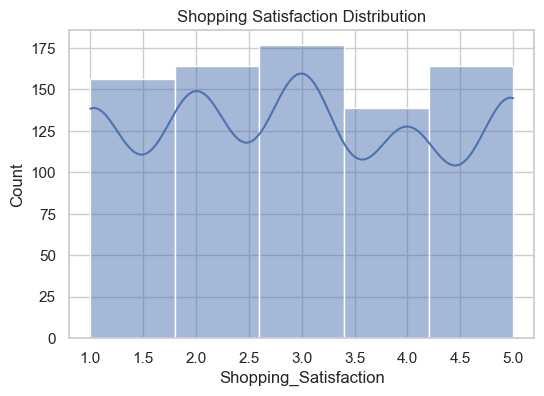

In [120]:
#Satisfaction Levels Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Shopping_Satisfaction"], bins=5, kde=True)
plt.title("Shopping Satisfaction Distribution")
plt.show()
#Most customers report moderate to high satisfaction, but there is a small portion with low satisfaction requiring attention.

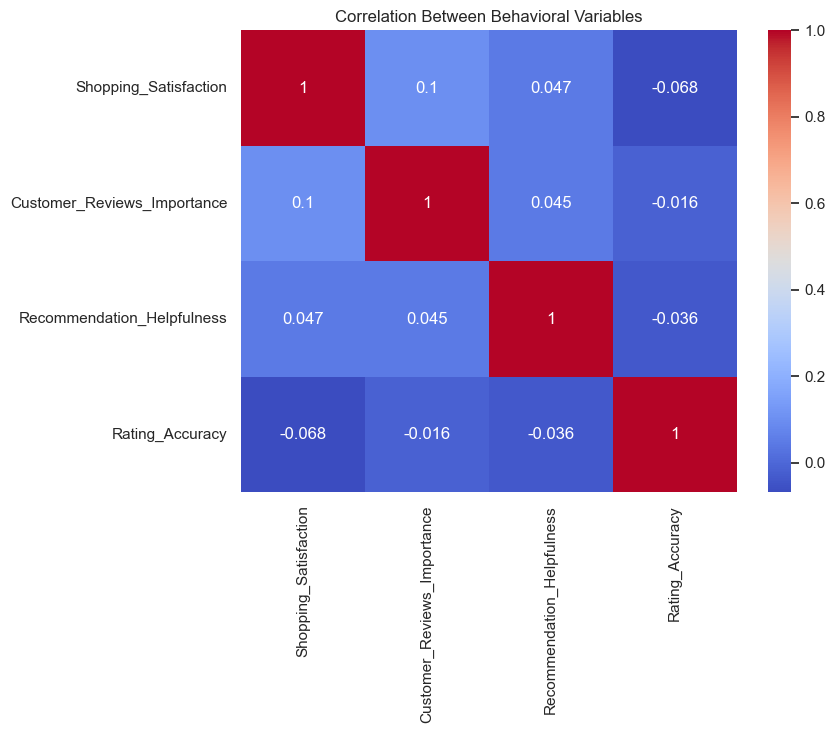

In [121]:
#Correlation Heatmap
behavior_cols = [
    "Shopping_Satisfaction",
    "Customer_Reviews_Importance",
    "Recommendation_Helpfulness",
    "Rating_Accuracy"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[behavior_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Behavioral Variables")
plt.show()
#Recommendation helpfulness shows positive correlation with shopping satisfaction, indicating effective recommendation systems increase satisfaction.

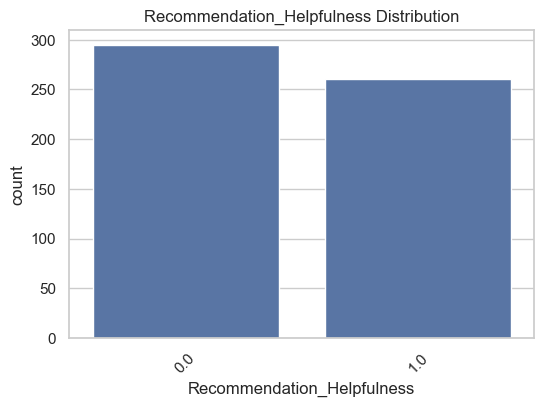

In [122]:
##Customer Segments Visualization
plt.figure(figsize=(6,4))
sns.countplot(x="Recommendation_Helpfulness", data=df)
plt.title("Recommendation_Helpfulness Distribution")
plt.xticks(rotation=45)
plt.show()
#Frequent buyers form a smaller but highly valuable segment compared to occasional shoppers.

In [ ]:
#Key Findings=====
#Electronics and Fashion are most preferred categories.
#Medium purchase frequency dominates customer base.
#Satisfaction levels are generally high.
#Recommendation helpfulness positively impacts satisfaction.
#At-risk customers show lower satisfaction and engagement.
#Cart abandonment is influenced by delivery charges and pricing.